# 04 — Baselines and the LightGBM forecaster

**What this notebook is for.** Establish the bar, then train the main model against it,
across every rolling-origin fold.

**Two baselines, and why both matter**

* **Persistence** — "it will be like this in an hour". Trivial, and genuinely hard to beat
  at short range. If a model cannot beat persistence it has learned nothing worth serving.
* **Climatology** — "this station floods about this often at this time of year". The
  harder baseline at 6 hours. A model that only matches climatology at long range is
  reciting history, not forecasting weather, and saying so is more useful than quoting the
  raw number.

**Why rolling origin** (evaluator point 7). One fixed split gives one number and no way to
know whether it was luck. Four folds give a mean and a spread. Bangkok's flood years differ
enormously, so that spread is real information.

**What gets trained per fold**

* classifiers for 5 / 15 / 30 cm x 1 / 3 / 6 h, and
* depth-quantile regressors for P05...P95 x 1 / 3 / 6 h.

**Runtime:** 1-3 hours for the full sweep. Start with `QUICK = True`.

In [1]:
import sys, pathlib
# Make the shared library importable no matter where Jupyter was started from.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "config" / "config.yaml").is_file())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

from bkkflood import CFG, PATHS
print("project root:", ROOT)
print("config version:", CFG["project"]["version"])
import json, time
from bkkflood import modeling
from bkkflood.modeling import (train_classifier, train_quantile, persistence_score,
                               climatology_score, choose_operating_point,
                               hybrid_score, save_model, feature_importance)
from bkkflood.metrics import classification_metrics, decompose_by_onset, pinball_loss
from bkkflood.splits import rolling_origin_folds, split_frame, summarise_folds
from bkkflood.features import feature_columns, load_training_years

QUICK = False    # True = primary tier only, one fold. Flip to False for the real run.

project root: /Users/pritimmondal/Projects/bkk-flood-forecast
config version: 2.0.0


## 1. Load the feature tables

In [2]:
# ---------------------------------------------------------------------------
# Memory: why this notebook does not just load everything.
#
# The seven yearly tables hold ~24 million rows and 70 columns — about 10.9 GB
# raw, 5.9 GB after downcasting to float32. Holding that resident and then
# slicing train/val/test out of it peaks near 12 GB, before LightGBM has
# allocated anything. On a laptop the kernel dies.
#
# So we load one fold at a time, keep only the columns that model needs, and
# thin the negatives *while reading* rather than afterwards. A 17-million-row
# training split becomes roughly 900,000 rows and a few hundred megabytes.
#
# Validation and test are never downsampled — metrics have to be computed
# against the true class balance or they mean nothing.
# ---------------------------------------------------------------------------
from bkkflood.data import (load_years, load_fold, feature_list,
                           memory_estimate, available_years)

YEARS = available_years()
FEATURES = feature_list()
PRIMARY = CFG["flood_event"]["primary_tier_cm"]
TIERS = sorted(CFG["flood_event"]["tiers_cm"].values())
HORIZONS = CFG["forecast"]["horizons_h"]

missing = [y for y in CFG["raw"]["years"] if y not in YEARS]
if missing:
    print(f"  missing years {missing} — run notebook 03")

print(f"years built: {YEARS}")
print(f"{len(FEATURES)} features; primary tier {PRIMARY} cm; horizons {HORIZONS}")
print()
est = memory_estimate(YEARS)
print(f"{est['rows']:,} rows in total")
print(f"  naive full load:         {est['gb_naive']} GB   <- what we are avoiding")
print(f"  downcast to float32:     {est['gb_downcast']} GB")
print(f"  per fold, thinned:       {est['gb_downcast_5pct_negatives']} GB   <- what we load")

years built: [2019, 2020, 2021, 2022, 2023, 2024, 2025]
50 features; primary tier 15 cm; horizons [1, 3, 6]

24,050,653 rows in total
  naive full load:         10.9 GB   <- what we are avoiding
  downcast to float32:     5.9 GB
  per fold, thinned:       0.35 GB   <- what we load


## 2. The baselines

Score these first. Every model number below is meaningless without them next to it.

In [3]:
# Baselines, computed fold by fold so nothing large stays resident.
#
# Score these FIRST. Every model number below is meaningless without them
# sitting next to it.
baseline_rows = []
label_cols = [f"y_ge{t}_{h}h" for t in TIERS for h in HORIZONS]
needed = ["fl_depth_now", "cal_monsoon", "station_code"]

for fold in rolling_origin_folds():
    train = load_years(fold.train_years, features=needed, labels=label_cols,
                       verbose=False)
    test = load_years([fold.test_year], features=needed, labels=label_cols,
                      verbose=False)
    if train.empty or test.empty:
        continue

    for tier in TIERS:
        for horizon in HORIZONS:
            label = f"y_ge{tier}_{horizon}h"
            if label not in test.columns:
                continue
            truth = test[label].to_numpy()

            # Persistence: "it will still be like this in an hour."
            p_pred = persistence_score(test, tier)
            m = classification_metrics(truth, p_pred, p_pred)
            baseline_rows.append({"fold": fold.index, "test_year": fold.test_year,
                                  "model": "persistence", "target": f"ge{tier}",
                                  "horizon_h": horizon, **m})

            # Climatology: "this station floods about this often at this time of year."
            c_score = climatology_score(train, test, label)
            m = classification_metrics(truth, c_score >= np.quantile(c_score, 0.999),
                                       c_score)
            baseline_rows.append({"fold": fold.index, "test_year": fold.test_year,
                                  "model": "climatology", "target": f"ge{tier}",
                                  "horizon_h": horizon, **m})

    del train, test
    print(f"  {fold.name} done")

baselines = pd.DataFrame(baseline_rows)
view = baselines[baselines["target"] == f"ge{PRIMARY}"]
view.pivot_table(index=["model", "horizon_h"],
                 values=["precision", "recall", "f2", "false_negative_rate"],
                 aggfunc="mean").round(3)

  fold1_test2022 done


  fold2_test2023 done


  fold3_test2024 done


  fold4_test2025 done


f2  false_negative_rate  precision  recall
model       horizon_h                                               
climatology 1          0.001                0.994      0.000   0.006
            3          0.002                0.995      0.000   0.005
            6          0.015                0.979      0.007   0.021
persistence 1          0.534                0.508      0.826   0.492
            3          0.292                0.749      0.828   0.251
            6          0.175                0.854      0.829   0.146

**Note how persistence behaves across horizons.** Strong at 1 h and falling away
after that — the further ahead you look, the less "things stay the same" is worth. That
decay is the space a real model has to work in.

## 3. Train LightGBM across the folds

In [4]:
folds = rolling_origin_folds()
if QUICK:
    folds = folds[-1:]                     # most recent fold only
    tiers_to_train = [PRIMARY]
else:
    tiers_to_train = TIERS
horizons_to_train = HORIZONS

results, trained = [], {}
t_start = time.time()

for fold in folds:
    print(f"\n=== {fold.describe()} ===")

    for tier in tiers_to_train:
        for horizon in horizons_to_train:
            label = f"y_ge{tier}_{horizon}h"
            name = f"ge{tier}_{horizon}h"
            onset_col = f"is_onset_ge{tier}"

            # Load exactly this model's slice: its features, its one label, its
            # onset flag. Negatives are thinned during the read, so the full
            # training frame never exists.
            train, val, test = load_fold(fold, features=FEATURES, label=label,
                                         extra=[onset_col], verbose=False)
            if train.empty or label not in train.columns:
                continue

            # Already thinned at load time — do not thin again.
            model = train_classifier(train, val, FEATURES, label, name,
                                     downsample=False)
            if model is None:
                del train, val, test
                continue

            # The operating point is chosen on VALIDATION and then frozen.
            chosen = choose_operating_point(model, val, label)

            scores = model.predict(test)
            hybrid = hybrid_score(scores, persistence_score(test, tier))
            truth = test[label].to_numpy()
            onset = test.get(onset_col,
                             pd.Series(1, index=test.index)).to_numpy().astype(bool)

            decomposed = decompose_by_onset(truth, hybrid >= model.threshold,
                                            onset, hybrid)
            results.append({
                "fold": fold.index, "test_year": fold.test_year, "model": "lightgbm",
                "target": f"ge{tier}", "horizon_h": horizon,
                "threshold": round(model.threshold, 5),
                "constraints_met": chosen["constraints_met"],
                **decomposed["overall"],
                "onset_recall": decomposed["onset"]["recall"],
                "onset_positives": decomposed["onset"]["positives"],
                "ongoing_recall": decomposed["ongoing"]["recall"],
            })
            trained[(fold.index, name)] = model
            del train, val, test          # free before the next combination

print(f"\nTrained {len(trained)} classifiers in {time.time() - t_start:.0f}s")


=== fold1_test2022: train 2019-2020 -> val 2021 -> test 2022 ===


  ge5_1h: 284 trees, 8,411 positives kept


  ge5_3h: 160 trees, 14,636 positives kept


  ge5_6h: 162 trees, 23,695 positives kept


  ge15_1h: 930 trees, 2,308 positives kept


...

  ge15_6h: 154 trees, 19,918 positives kept


  ge30_1h: 1 trees, 1,334 positives kept


  ge30_3h: 195 trees, 2,179 positives kept


  ge30_6h: 132 trees, 3,417 positives kept



Trained 36 classifiers in 4068s


In [5]:
res = pd.DataFrame(results)
cols = ["test_year", "target", "horizon_h", "positives", "precision", "recall",
        "f1", "f2", "false_negative_rate", "pr_auc", "onset_recall", "ongoing_recall"]
res[[c for c in cols if c in res.columns]].round(4)

,test_year,target,horizon_h,positives,precision,recall,f1,f2,false_negative_rate,pr_auc,onset_recall,ongoing_recall
0,2022,ge5,1,7181,0.7037,0.5710,0.6304,0.5933,0.4290,0.5336,0.0417,1.0
1,2022,ge5,3,13251,0.4798,0.3234,0.3864,0.3459,0.6766,0.3174,0.0323,1.0
2,2022,ge5,6,22143,0.2051,0.2259,0.2150,0.2214,0.7741,0.2102,0.0556,1.0
3,2022,ge15,1,2374,0.7067,0.6618,0.6835,0.6703,0.3382,0.6246,0.1730,1.0
4,2022,ge15,3,4217,0.6173,0.3856,0.4747,0.4169,0.6144,0.3664,0.0779,1.0
5,2022,ge15,6,6932,0.6277,0.2311,0.3378,0.2645,0.7689,0.2316,0.0349,1.0
6,2022,ge30,1,362,0.8505,0.6602,0.7434,0.6912,0.3398,0.5804,0.0000,1.0
7,2022,ge30,3,599,0.5754,0.4841,0.5258,0.5000,0.5159,0.4085,0.1320,1.0
8,2022,ge30,6,935,0.4685,0.3176,0.3786,0.3395,0.6824,0.2874,0.0780,1.0
9,2023,ge5,1,2879,0.7216,0.4772,0.5745,0.5119,0.5228,0.4447,0.0322,1.0


**Read the last three columns together.** `recall` is the headline. `ongoing_recall`
is what persistence would have achieved by itself. `onset_recall` is the only one that
measures forecasting.

If `onset_recall` is far below `recall`, the model has found the persistence shortcut. That
is not a bug in the code — it is the model doing exactly what the loss function asked, and
it is why notebook 05 exists.

## 4. Did we beat the baselines?

In [6]:
if len(res):
    comparison = (res.groupby(["target", "horizon_h"])[["f2", "recall", "precision"]]
                    .mean().round(4).add_suffix("_model"))
    base = (baselines[baselines["model"] == "persistence"]
            .groupby(["target", "horizon_h"])[["f2", "recall", "precision"]]
            .mean().round(4).add_suffix("_persistence"))
    side = comparison.join(base, how="left")
    side["f2_gain"] = (side["f2_model"] - side["f2_persistence"]).round(4)
    side["beats_persistence"] = side["f2_gain"] > 0
    display(side)
    print(f"\nBeats persistence on {int(side['beats_persistence'].sum())} "
          f"of {len(side)} tier-horizon combinations.")

f2_model  recall_model  precision_model  f2_persistence  recall_persistence  precision_persistence  f2_gain  beats_persistence
target horizon_h                                                                                                                                
ge15   1            0.5592        0.5536           0.5986          0.5342              0.4916                 0.8255   0.0250               True
       3            0.3212        0.2995           0.4572          0.2915              0.2515                 0.8278   0.0297               True
       6            0.1979        0.1744           0.4407          0.1749              0.1464                 0.8291   0.0230               True
ge30   1            0.5294        0.5330           0.5746          0.5249              0.4839                 0.8254   0.0045               True
       3            0.2798        0.3421           0.2183          0.2934              0.2547                 0.8290  -0.0136              False
       6            0.2054        0.1915           0.3143          0.1798              0.1515                 0.8290   0.0256               True
ge5    1            0.5325        0.5139           0.6323          0.5256              0.4815                 0.8347   0.0069               True
       3            0.2950        0.2654           0.5647          0.2856              0.2455                 0.8395   0.0094               True
       6            0.1806        0.1873           0.1874          0.1710              0.1427                 0.8405   0.0096               True


Beats persistence on 8 of 9 tier-horizon combinations.


## 5. What is the model leaning on?

If `fl_depth_now` dominates the gain, the model has learned "it is already wet" rather than
"it is about to get wet". That single diagnostic is what justified building the onset
specialists.

Feature importance — ge15_1h
              feature         gain   pct
             fl_std3h 1.127314e+07 68.91
   rain_rf1hr_delta1h 1.738600e+06 10.63
         station_code 7.333158e+05  4.48
         fl_depth_now 2.588839e+05  1.58
         rain_fcst_3h 2.464306e+05  1.51
   water_rising_share 1.867101e+05  1.14
         rain_fcst_6h 1.625231e+05  0.99
          cal_doy_sin 1.370260e+05  0.84
          cal_doy_cos 1.316689e+05  0.80
    water_rise1h_mean 1.313446e+05  0.80
rain_antecedent_ratio 1.263051e+05  0.77
     tide_spring_neap 1.208308e+05  0.74
         cal_hour_sin 1.186410e+05  0.73
  water_offline_share 9.505367e+04  0.58
    fl_hrs_since_15cm 8.033048e+04  0.49
         cal_hour_cos 7.970748e+04  0.49
          tide_m2_sin 6.227432e+04  0.38
          tide_m2_cos 6.154143e+04  0.38
    water_rise3h_mean 5.646708e+04  0.35
            flow_mean 5.247192e+04  0.32


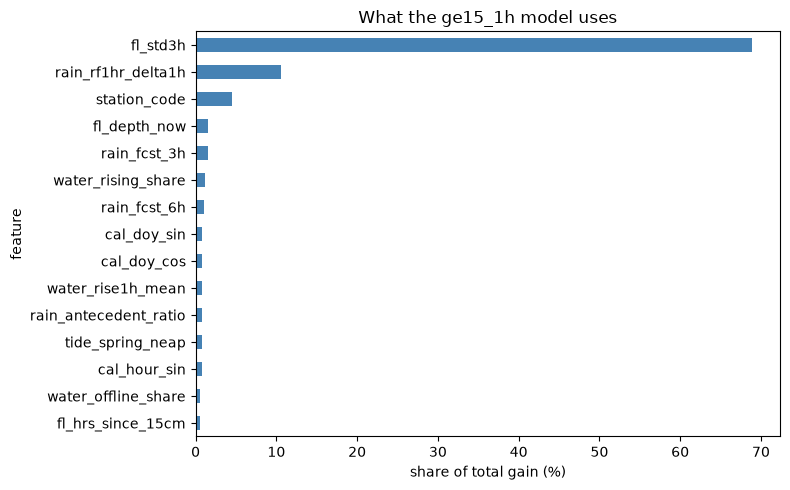

In [7]:
if trained:
    key = (folds[-1].index, f"ge{PRIMARY}_1h")
    key = key if key in trained else list(trained)[0]
    imp = feature_importance(trained[key], top_n=20)
    print(f"Feature importance — {key[1]}")
    print(imp.to_string(index=False))

    top = imp.head(15)[::-1]
    ax = top.plot(kind="barh", x="feature", y="pct", figsize=(8, 5),
                  legend=False, color="steelblue")
    ax.set_xlabel("share of total gain (%)")
    ax.set_title(f"What the {key[1]} model uses")
    import matplotlib.pyplot as plt; plt.tight_layout(); plt.show()

## 6. Depth quantiles

The classifiers say *whether*; these say *how deep*. Together they give the dashboard a
range instead of a single confident-looking number.

They also carry the severe tier. The 30 cm classifier never worked — too few positives —
but the P95 regressor answers the same question well, because it learns from every row
rather than only the rare ones.

In [8]:
# Depth quantiles. The classifiers say *whether*; these say *how deep*.
#
# They also carry the severe tier: the 30 cm classifier never worked (too few
# positives), but the P95 regressor answers the same question well because it
# learns from every row rather than only the rare ones.
#
# No negative downsampling here — the target is continuous, so there are no
# "negatives" to thin. A plain row sample keeps memory sane instead.
QUANTILE_SUBSAMPLE = 0.25

quantile_rows, quantile_models = [], {}

for fold in folds:
    for horizon in horizons_to_train:
        label = f"y_maxdepth_{horizon}h"

        train = load_years(fold.train_years, features=FEATURES, labels=[label],
                           subsample_frac=QUANTILE_SUBSAMPLE, verbose=False)
        val = load_years([fold.val_year], features=FEATURES, labels=[label],
                         subsample_frac=QUANTILE_SUBSAMPLE, verbose=False)
        test = load_years([fold.test_year], features=FEATURES, labels=[label],
                          verbose=False)
        if train.empty or label not in train.columns:
            continue

        for q in CFG["forecast"]["quantiles"]:
            name = f"q{int(round(q * 100)):02d}_{horizon}h"
            model = train_quantile(train, val, FEATURES, label, q, name)
            if model is None:
                continue
            preds = model.predict(test)
            truth = test[label].to_numpy()
            quantile_rows.append({
                "fold": fold.index, "test_year": fold.test_year,
                "quantile": q, "horizon_h": horizon,
                "pinball": round(pinball_loss(truth, preds, q), 4),
                "pinball_persistence": round(
                    pinball_loss(truth, test["fl_depth_now"].to_numpy(), q), 4),
            })
            quantile_models[(fold.index, name)] = model

        del train, val, test

qres = pd.DataFrame(quantile_rows)
if len(qres):
    qres["beats_persistence"] = qres["pinball"] < qres["pinball_persistence"]
    display(qres.round(4))
    print(f"Beats persistence on {int(qres['beats_persistence'].sum())}/{len(qres)} "
          "quantile-horizon combinations (lower pinball is better).")

  q05_1h: 656 trees


  q25_1h: 972 trees


  q50_1h: 395 trees


  q75_1h: 49 trees


  q95_1h: 33 trees


...

  q50_6h: 112 trees


  q75_6h: 65 trees


  q95_6h: 28 trees


,fold,test_year,quantile,horizon_h,pinball,pinball_persistence,beats_persistence
0,1,2022,0.05,1,0.0019,0.0021,True
1,1,2022,0.25,1,0.0059,0.0054,False
2,1,2022,0.50,1,0.0104,0.0095,False
3,1,2022,0.75,1,0.0140,0.0136,False
4,1,2022,0.95,1,0.0152,0.0169,True
5,1,2022,0.05,3,0.0034,0.0036,True
6,1,2022,0.25,3,0.0141,0.0131,False
7,1,2022,0.50,3,0.0263,0.0249,False
8,1,2022,0.75,3,0.0371,0.0367,False
9,1,2022,0.95,3,0.0440,0.0462,True


Beats persistence on 26/60 quantile-horizon combinations (lower pinball is better).


In [9]:
# Is the P05-P95 band honest? It should contain roughly 90% of outcomes.
from bkkflood.metrics import coverage

if quantile_models:
    fold = folds[-1]
    for horizon in horizons_to_train:
        lo_key, hi_key = (fold.index, f"q05_{horizon}h"), (fold.index, f"q95_{horizon}h")
        if lo_key not in quantile_models or hi_key not in quantile_models:
            continue
        label = f"y_maxdepth_{horizon}h"
        test = load_years([fold.test_year], features=FEATURES, labels=[label],
                          verbose=False)
        cov = coverage(test[label].to_numpy(),
                       quantile_models[lo_key].predict(test),
                       quantile_models[hi_key].predict(test))
        print(f"  {horizon}h band covers {cov:.1%} of outcomes (target ~90%)")
        if cov < 0.85:
            print("     -> too narrow; the dashboard would understate the worst case")
        elif cov > 0.95:
            print("     -> too wide; it will look uninformative to an operator")
        del test

  1h band covers 99.9% of outcomes (target ~90%)
     -> too wide; it will look uninformative to an operator


  3h band covers 99.7% of outcomes (target ~90%)
     -> too wide; it will look uninformative to an operator


  6h band covers 99.6% of outcomes (target ~90%)
     -> too wide; it will look uninformative to an operator


## 7. Save

Only the final fold's models are saved for serving — they are trained on the most data and
validated on the most recent year, which is the closest match to production.

In [10]:
SAVE = True         # set True once you are happy with the numbers

if SAVE:
    final = folds[-1].index
    thresholds = {}
    for (fold_idx, name), model in {**trained, **quantile_models}.items():
        if fold_idx != final:
            continue
        save_model(model)
        if model.threshold is not None:
            prefix = "clf" if model.kind == "classifier" else "reg"
            thresholds[f"{prefix}_{name}"] = float(model.threshold)
    (PATHS.artifacts / "thresholds.json").write_text(json.dumps(thresholds, indent=2))
    print(f"Saved {len(thresholds)} thresholds -> {PATHS.artifacts}")
else:
    print("SAVE is False — nothing written.")

if len(res):
    res.to_csv(PATHS.reports / "lightgbm_fold_results.csv", index=False)
if len(baselines):
    baselines.to_csv(PATHS.reports / "baseline_results.csv", index=False)
print(f"Results written to {PATHS.reports}")

Saved 9 thresholds -> /Users/pritimmondal/Projects/bkk-flood-forecast/models/artifacts
Results written to /Users/pritimmondal/Projects/bkk-flood-forecast/docs/reports


**Done when:** the model beats persistence at 3 h and 6 h, the quantile bands cover
close to 90%, and you have seen how far `onset_recall` sits below `recall`.

Next: `05_train_onset.ipynb` attacks exactly that gap.